# FIPO完整训练循环框架
- 这是一个基于 PyTorch 构建的 FIPO (Future-KL Influenced Policy Optimization) 完整训练循环框架。
- 该代码将 **Rollout（采样）、Advantage（优势估计）、FutureKL 计算以及 Loss 更新**这几个核心环节串联在了一起。

为了保持逻辑清晰，代码中省略了真实的 Tokenizer 和 LLM 生成逻辑，采用模拟数据（Mock Data）来演示整个数据流转和梯度更新的过程。

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ==========================================
# 1. 核心组件：FIPO Loss 函数
# ==========================================
class FIPOLoss(nn.Module):
    """
    FIPO 损失函数，封装了 FutureKL 计算、安全掩码与 PPO-Clip 目标
    """
    def __init__(self, clip_epsilon=0.2, gamma=0.9, safety_threshold=10.0, f_high=0.2):
        super(FIPOLoss, self).__init__()
        self.clip_epsilon = clip_epsilon
        self.gamma = gamma
        self.safety_threshold = safety_threshold
        self.f_max = 1.0 + f_high

    def forward(self, log_probs_new, log_probs_old, advantages, future_log_probs_diff):
        # 1. 计算重要性采样比率 (在对数空间做减法保证稳定)
        log_ratio = log_probs_new - log_probs_old
        ratio = torch.exp(log_ratio)
        
        # 2. 计算安全掩码 M_k (极端值过滤)
        '''
        它的核心作用是：构建一个“安全掩码”，将布尔类型的安全判断转化为浮点数权重，
                     以便后续进行数学运算（如加权平均或梯度屏蔽）
                     
        is_safe生成一个布尔张量（Boolean Tensor）,如果比率小于阈值，对应位置为 True（安全），否则为 False（危险/截断）
        
        .unsqueeze(-1):含义：在张量的最后一个维度增加一个维度（大小为 1）,加上后形状变为 [B, 1]，就可以正确地应用到 [B, D] 的每一列上
        
        '''
        is_safe = (ratio < self.safety_threshold).unsqueeze(-1)
        '''
        含义：将布尔张量转换为浮点型张量。
        数值变化：
           True  →→ 1.0
           False →→ 0.0
           
        目的：在 PyTorch/TensorFlow 中，布尔值不能直接参与复杂的梯度计算或矩阵乘法。
        将其转换为 0.0 和 1.0 的浮点数后，它就变成了一个标准的掩码。
        '''
        m_k = is_safe.float()
        
        # 3. 计算 FutureKL (带指数衰减)
        '''
        fipo算法中最核心的“未来感知”模块。
        它的物理意义是：评估当前时间步 t 的决策，对后续未来H 步策略变化趋势的累积影响。
        
        通过引入指数衰减（ γ ）和安全掩码（ Mk），算法能够智能地判断：未来的策略变化是“健康且稳定”的，还是“危险且失控”的。
        '''
        '''
        horizon这代表算法向前看的“未来步数”（Horizon）。
        例如，如果 horizon = 5，表示当前时间步 t 会评估未来 5 个时间步（ t+1 到 t+5 ）的策略偏移量 Δlogp k
        '''
        horizon = future_log_probs_diff.shape[-1]
        time_steps = torch.arange(1, horizon + 1, device=log_probs_new.device)
        '''
        计算指数衰减因子（Discounts）:
        
        - self.gamma ** time_steps：对衰减系数 γ （通常 0<γ<1 ，如 0.9）进行幂运算，得到 [0.9, 0.81, 0.729, ...]。
        - .view(1, 1, -1)：将一维张量重塑为三维张量 [1, 1, Horizon]
        
        物理意义：时间衰减机制。在强化学习中，越近的未来对当前的影响越大，越远的未来影响越小。通过指数衰减，算法赋予了近期未来更高的权重，防止过远的未来信号产生过度干扰。
        
        工程意义：.view(1, 1, -1) 是为了广播机制（Broadcasting）。因为 future_log_probs_diff 的形状是 [Batch, Seq_Len, Horizon]，将 discounts 变成 [1, 1, Horizon] 后，PyTorch 可以自动将其广播到所有的 Batch 和时间步上进行逐元素相乘。
        '''
        discounts = (self.gamma ** time_steps).view(1, 1, -1)
        '''
        .sum(dim=-1)：在最后一个维度（Horizon 维度）上进行求和。
        
        物理意义：将未来 H 步的分散信号，压缩成了一个单一的标量值 FutureKL_t。
        - 如果结果为较大的正数：说明未来的策略在稳定地增强（鼓励），当前步可以大胆更新。
        - 如果结果为负数或接近 0：说明未来的策略在衰退，或者触发了安全掩码（ m_k=0 ），当前步应该保守更新。
        '''
        future_kl_raw = (m_k * discounts * future_log_probs_diff).sum(dim=-1)
        
        # 4. 计算调制因子 f_t (影响力权重裁剪)
        '''
        这段代码是 FIPO 算法中将“未来趋势信号”转化为“实际梯度缩放系数”的关键桥梁。
        
        它的核心作用是：将 FutureKL 的原始累积值（可能为负无穷到正无穷）映射为一个安全的、有界的乘法权重 f_t，用来动态调节 PPO 目标函数中优势函数（Advantage）的幅度。
        '''
        '''
        torch.exp(future_kl_raw) 
        指数映射：从“加法空间”回到“乘法空间”
        
        为什么需要这一步？
        在之前的步骤中，future_kl_raw 是通过对数概率差（ Δlogp ）累加得到的，它处于对数空间（Log Space）。
        在对数空间中，未来的影响是“加法”关系。
        但在 PPO 的目标函数中，我们需要的是一个乘法因子（即 hat{A_t} =  A_t ⋅f_t）。
        
        如果 future_kl_raw > 0，exp 后结果大于 1，表示未来趋势向好。
        如果 future_kl_raw < 0，exp 后结果小于 1，表示未来趋势变差。
        如果 future_kl_raw = 0，exp 后结果等于 1，表示未来没有明显变化
        
        '''
        
        '''
        torch.clamp(..., min=1.0, max=self.f_max)
        安全裁剪：防止梯度爆炸与过度惩罚
        数学含义：将指数映射后的值强制限制在 [1.0,self.f_max] 的区间内。
        
        为什么要限制下界为 1.0？
        在 FIPO 的设计中，对于表现出过高重要性比率（即非常危险或异常）的负优势样本，
        算法会触发安全掩码（ Mk=0 ），此时 future_kl_raw 会变成 0 或负数。
        将 ft的下界设为 1.0，意味着即使未来趋势看起来不好，当前步的更新幅度也不会被削弱（至少保持原始的 PPO 更新力度）。
        这有效防止了模型在失败序列中因为过度惩罚好 Token 而导致训练崩溃。
        
        为什么要限制上界为 self.f_max？
        如果 future_kl_raw 非常大（例如等于 5），exp(5) ≈ 148。
        如果直接用 148 去乘 Advantage，会导致梯度瞬间爆炸，模型参数发生剧烈震荡。
        通过设置上限（例如 self.f_max = 1.2），算法确保了最激进的放大倍数也被严格控制在 1.2 倍以内。
        
        
        f_t 变成了一个动态的、安全的策略更新阀门：
        - 当 ft=1.0 时：相当于标准的 PPO 算法，正常更新。
        - 当 1.0<f_t≤self.f_max 时：FIPO 判定当前 Token 是一个“关键的正向锚点”（它的决策让后续推理变得更自信、更连贯），因此放大该 Token 的梯度信号，加速学习。
        - （注：如果代码逻辑允许 f_t<1.0 ）：则说明当前 Token 对后续轨迹产生了负面影响（如引发了 Oops Moment），此时会衰减该 Token 的更新幅度，防止错误传播
        
        '''
        f_t = torch.clamp(torch.exp(future_kl_raw), min=1.0, max=self.f_max)
        
        # 5. 计算 FIPO 目标函数 (重加权 PPO-Clip)
        surr1 = ratio * f_t * advantages
        clipped_ratio = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon)
        surr2 = clipped_ratio * f_t * advantages
        
        objective = torch.min(surr1, surr2)
        loss = -objective.mean()
        
        return loss, f_t.detach().mean()


# ==========================================
# 2. 模拟 Actor 模型
# ==========================================
class MockActor(nn.Module):
    def __init__(self, vocab_size, hidden_dim):
        super(MockActor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.linear = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, input_ids):
        x = self.embedding(input_ids)
        logits = self.linear(x)
        log_probs = torch.log_softmax(logits, dim=-1)
        return log_probs


# ==========================================
# 3. FIPO 完整训练循环
# ==========================================
def train_fipo():
    # 参数配置
    batch_size, seq_len, horizon = 8, 32, 5
    vocab_size, hidden_dim = 1000, 256
    epochs = 10
    
    # 初始化组件
    actor = MockActor(vocab_size, hidden_dim)
    optimizer = optim.Adam(actor.parameters(), lr=1e-4)
    fipo_loss_fn = FIPOLoss()
    
    print("Starting FIPO Training Loop...")
    for epoch in range(epochs):
        # --- Step 1: Rollout (采样阶段) ---
        # 模拟生成一批 input_ids
        mock_input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
        
        # 使用旧策略生成轨迹并记录 log_probs
        with torch.no_grad():
            old_log_probs = actor(mock_input_ids)
            # 模拟采样动作 (这里简化为直接取最大概率的 token 作为动作)
            actions = old_log_probs.argmax(dim=-1)
            # 提取对应动作的 log_prob
            old_log_probs = old_log_probs.gather(2, actions.unsqueeze(-1)).squeeze(-1)
            
        # --- Step 2: Advantage 估计 ---
        # 实际中由 Critic 模型或 GAE 计算得出，这里模拟随机优势值
        advantages = torch.randn(batch_size, seq_len) 
        
        # --- Step 3: 准备 Future Log Probs Diff ---
        # 模拟未来 horizon 步的 log_prob 差值 (log_p_new - log_p_old)
        future_diffs = torch.randn(batch_size, seq_len, horizon) * 0.1
        
        # --- Step 4: FIPO Loss 更新 ---
        # 开启梯度计算
        new_log_probs_full = actor(mock_input_ids)
        new_log_probs = new_log_probs_full.gather(2, actions.unsqueeze(-1)).squeeze(-1)
        
        # 计算 Loss 并反向传播
        loss, avg_f_t = fipo_loss_fn(new_log_probs, old_log_probs, advantages, future_diffs)
        
        optimizer.zero_grad()
        loss.backward()
        
        # 防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)
        optimizer.step()
        
        print(f"Epoch [{epoch+1}/{epochs}] | FIPO Loss: {loss.item():.4f} | Avg f_t: {avg_f_t.item():.4f}")

if __name__ == "__main__":
    train_fipo()

## 代码架构解析
1. FIPOLoss 类：
  - 完全封装了 FIPO 的数学逻辑。它接收新策略的 Log-Prob、旧策略的 Log-Prob、优势估计以及未来的 Log-Prob 差异，输出最终的 Loss 和用于监控的$f_t$均值。
2. Rollout 模拟：
  - <font color='red'>在实际的 RLHF 框架（如 VeRL 或 TRL）中，这一步会调用 LLM 的 generate 方法。</font>
    - 这里我们使用 MockActor 模拟了采样过程，并将旧策略的 log_probs 存入缓存。
3. Advantage 模拟：
  - 在实际流程中，这一步需要运行 Reward Model 打分，并通过 GAE (Generalized Advantage Estimation) 计算优势。这里使用随机张量代替，以聚焦于 FIPO 的梯度更新逻辑。
4. 训练闭环：
  - 在 train_fipo 中，我们重新前向传播获取 new_log_probs，然后将其与缓存的 old_log_probs 一起传入 FIPOLoss。通过 loss.backward() 和 optimizer.step() 完成单步策略更新。

你可以直接将这段代码复制到本地 Python 环境中运行，观察 FIPO Loss 的下降趋势以及 Avg $f_t $的动态变化。

# 补一段 GAE 的计算代码，把 Advantage 的生成也补上

补上 GAE（广义优势估计）的代码后，整个 RLHF 训练循环就彻底闭环了！
- GAE 的核心作用是“<font color='red'>连接未来</font>”：
  - 它通过结合即时奖励（Reward）和 Critic 网络对未来状态的估值（Value），**计算出一个衡量当前动作“到底比平均水平好多少”的优势值（Advantage）**。

下面我为你补全这段代码，并将其无缝嵌入到之前的 FIPO 训练循环中。

## 核心 GAE 计算模块
- GAE 的工程实现有一个关键细节：
  - **必须从后向前（Reversed）计算**，<font color='red'>因为当前时间步的优势依赖于下一个时间步的累积值。同时，必须正确处理回合结束标志（dones），遇到终止状态时，未来的累积值必须清零。</font>

In [ ]:
import torch

def compute_gae(rewards, values, next_value, dones, gamma=0.99, gae_lambda=0.95):
    """
    广义优势估计 (GAE) 计算
    
    Args:
        rewards: 即时奖励序列 [Batch, Seq_Len]
        values: 当前状态的 Critic 估值 [Batch, Seq_Len]
        next_value: 最后一个状态的估值 [Batch, 1]
        dones: 回合结束标志 (1.0=结束, 0.0=继续) [Batch, Seq_Len]
        gamma: 奖励折扣因子
        gae_lambda: GAE 平滑参数 (控制偏差与方差的平衡)
        
    Returns:
        advantages: 优势估计 [Batch, Seq_Len]
        returns: 目标回报 (用于训练 Critic) [Batch, Seq_Len]
    """
    advantages = torch.zeros_like(rewards)
    last_gae = 0.0
    
    # 【关键】从后向前反向遍历时间步
    for t in reversed(range(rewards.shape[1])):
        if t == rewards.shape[1] - 1:
            next_nonterminal = 1.0 - dones[:, t]
            next_values = next_value
        else:
            next_nonterminal = 1.0 - dones[:, t]
            next_values = values[:, t + 1]
            
        # 1. 计算时间差分误差 (TD Error): delta = r + gamma * V(s') - V(s)
        delta = rewards[:, t] + gamma * next_values * next_nonterminal - values[:, t]
        
        # 2. 递归计算 GAE: gae = delta + gamma * lambda * gae_next
        last_gae = delta + gamma * gae_lambda * next_nonterminal * last_gae
        
        advantages[:, t] = last_gae
        
    # 3. 计算目标回报: Returns = Advantages + Values
    returns = advantages + values
    
    return advantages, returns

## 整合后的完整 FIPO 训练循环
现在，我们把 compute_gae 接入到之前的 train_fipo 函数中，形成一个包含 Actor（策略网络） 和 Critic（价值网络） 的完整闭环：

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. 模拟 Critic 模型 (用于 GAE)
# ==========================================
class MockCritic(nn.Module):
    def __init__(self, vocab_size, hidden_dim):
        super(MockCritic, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.linear = nn.Linear(hidden_dim, 1)
        
    def forward(self, input_ids):
        x = self.embedding(input_ids)
        # 输出单个标量值，表示当前状态的预期回报
        value = self.linear(x.mean(dim=1)).squeeze(-1) 
        return value


# ==========================================
# 2. 完整的 FIPO 训练循环 (含 GAE)
# ==========================================
def train_fipo_with_gae():
    # 参数配置
    batch_size, seq_len, horizon = 8, 32, 5
    vocab_size, hidden_dim = 1000, 256
    epochs = 10
    
    # 初始化组件
    actor = MockActor(vocab_size, hidden_dim)
    critic = MockCritic(vocab_size, hidden_dim)
    
    # 分别优化 Actor 和 Critic
    actor_optimizer = optim.Adam(actor.parameters(), lr=1e-4)
    critic_optimizer = optim.Adam(critic.parameters(), lr=3e-4)
    
    fipo_loss_fn = FIPOLoss()
    
    print("Starting FIPO Training Loop with GAE...")
    for epoch in range(epochs):
        # --- Step 1: Rollout (采样阶段) ---
        mock_input_ids = torch.randint(0, vocab_size, (batch_size, seq_len))
        
        with torch.no_grad():
            # 获取旧策略的 Log Probs
            old_log_probs_full = actor(mock_input_ids)
            actions = old_log_probs_full.argmax(dim=-1)
            old_log_probs = old_log_probs_full.gather(2, actions.unsqueeze(-1)).squeeze(-1)
            
            # 获取旧 Critic 的估值
            old_values = critic(mock_input_ids)
            
        # --- Step 2: 模拟环境与奖励 ---
        # 实际中这里调用 env.step() 或 Reward Model
        mock_rewards = torch.randn(batch_size, seq_len) * 0.1  
        mock_dones = torch.zeros(batch_size, seq_len)        # 假设序列中间没有结束
        
        # --- Step 3: GAE 优势估计 ---
        with torch.no_grad():
            # 获取最后一步的 next_value
            next_value = critic(mock_input_ids)[:, -1].unsqueeze(-1) 
            
            advantages, returns = compute_gae(
                rewards=mock_rewards, 
                values=old_values, 
                next_value=next_value, 
                dones=mock_dones
            )
            
            # 【工程最佳实践】对优势进行标准化，防止梯度爆炸
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # --- Step 4: 准备 Future Log Probs Diff ---
        future_diffs = torch.randn(batch_size, seq_len, horizon) * 0.1
        
        # --- Step 5: FIPO Loss 更新 ---
        new_log_probs_full = actor(mock_input_ids)
        new_log_probs = new_log_probs_full.gather(2, actions.unsqueeze(-1)).squeeze(-1)
        
        # 更新 Actor (策略网络)
        fipo_loss, avg_f_t = fipo_loss_fn(new_log_probs, old_log_probs, advantages, future_diffs)
        actor_optimizer.zero_grad()
        fipo_loss.backward()
        torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)
        actor_optimizer.step()
        
        # 更新 Critic (价值网络，使其预测更接近真实的 Returns)
        # 这里使用简单的 MSE Loss
        current_values = critic(mock_input_ids)
        critic_loss = nn.MSELoss()(current_values, returns)
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()
        
        print(f"Epoch [{epoch+1}/{epochs}] | FIPO Loss: {fipo_loss.item():.4f} | Critic Loss: {critic_loss.item():.4f} | Avg f_t: {avg_f_t.item():.4f}")

if __name__ == "__main__":
    train_fipo_with_gae()

## 代码架构的闭环逻辑
- Critic 的引入：GAE 需要 values（状态估值）。因此我们增加了一个 MockCritic，它的输出是一个标量，代表当前状态下预期的未来总奖励。
- 数据流转：
  - 采样得到 old_values 和 rewards。
  - 通过 compute_gae 算出 advantages（给 Actor 用）和 returns（给 Critic 用）。
- 双网络更新：
  - Actor 通过 FIPO Loss 更新，它利用 advantages 知道哪些动作该鼓励，并利用 f_t 知道该鼓励多大力度。
  - Critic 通过 MSE Loss 更新，它的目标是让自己的估值 current_values 尽可能逼近 GAE 算出的真实目标 returns。Critic 越准，Actor 的 advantages 就越可靠。
  
至此，从底层的对数概率计算、KL 散度、PPO-Clip，到 FIPO 的未来信号调制，再到 GAE 的优势估计，整个 RLHF 强化学习框架的底层核心逻辑已经全部打通！

# grpo通过从组中筛选最优，替代了GAE

- 在传统的 PPO 算法中，GAE（广义优势估计）的计算高度依赖一个与策略模型同等规模的价值模型（Critic）来提供基线（Baseline）。这不仅让训练成本翻倍，还容易因为价值模型的评估不准而导致训练不稳定。

- <font color='red'>GRPO 巧妙地摒弃了显式的价值模型（Critic），转而采用“组内相对评估”的机制来替代 GAE。</font>
  - 它的核心思想可以概括为：不比绝对分，只比相对名次。

## 具体来说，GRPO 通过以下三个步骤完成了对 GAE 的替代：
1. 组采样 (Group Sampling)：
  - 对于同一个提示词（Prompt），让当前的策略模型并行采样生成一组（比如 k 个）不同的回复（候选轨迹），组成一个“评估小组”。
2. 组评估 (Group Evaluation)：
  - 使用奖励模型（RM）或可验证的规则（如代码是否运行成功、数学题答案是否正确）为这组回复中的每一个打分，得到奖励分数 $r_i$
3. 组内优势计算 (Group-Relative Advantage Estimation)：
  - 计算这组回复的平均奖励 $r^ˉ$ 和标准差 $σ_r$。然后，将每个回复的奖励减去平均值并除以标准差，得到归一化后的优势值（Advantage）：

$A_i = \frac{r_i - r^ˉ}{σ_r}$

在这个公式中，组内平均奖励 $r^ˉ$完美替代了 PPO 中由 Critic 网络输出的状态价值 
V(s) 作为基线。高于平均水平的回复获得正向优势，低于平均水平的获得负向优势。

## 这种替代带来的巨大优势：
- 极致的降本增效：
  - 直接省去了庞大且昂贵的价值网络（Critic），使得显存占用降低了 40%-50%，训练速度显著提升。
- 训练更加稳定：
  - 因为模型学习的是“在同样条件下，A回复比B回复好”的相对关系，这种比较对奖励分数的绝对数值不敏感，有效缓解了奖励模型评分波动带来的干扰，降低了方差。
  
可以说，GRPO 用一场高效的“小组内部评比”，替代了复杂且昂贵的“外部专家评分”，为大模型的高效微调打开了一扇新的大门。


# GRPO与PPO的目标函数对比

将 GRPO 与 PPO 的目标函数放在一起进行逐项对比，是理解 GRPO 核心创新（即“去 Critic 化”）最直观的方式。以下是两者的完整数学表达式及深度拆解：



In [1]:
from IPython.display import Image

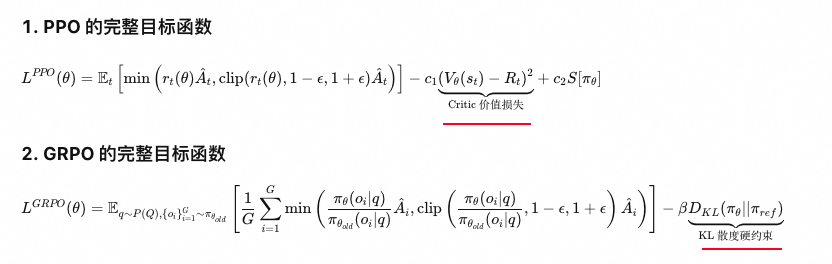

In [2]:
Image(filename='./Image/ppo_grpo.png')

## 逐项对比与“去 Critic”机制解析 

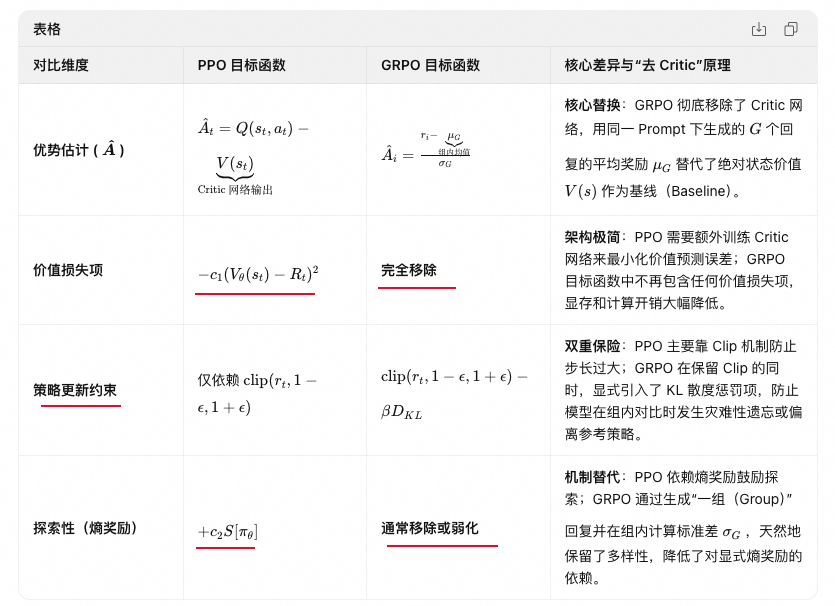

In [4]:
Image(filename='./Image/critic_without.png')

## 总结
从公式中可以清晰地看到，GRPO 并非对 PPO 进行了颠覆性的重构，而是极其精准地“做减法”：
1. 拿掉 Critic：将依赖外部价值网络的绝对评估，替换为组内统计量（均值和标准差）的相对评估。
2. 拿掉价值损失：省去了训练价值网络所需的反向传播和显存占用。
3. 强化 KL 约束：为了弥补没有 Critic 可能带来的方差增大问题，GRPO 将 KL 散度直接作为正则项加入目标函数，起到了稳定训练的“刹车”作用。

这种“组内相对优势”的设计，使得 GRPO 在保持 PPO 训练稳定性的同时，实现了大模型强化学习（RLHF）训练效率的飞跃。

# 从轨迹构造 future_log_probs_diff

太棒了！补上这一步，整个 FIPO 框架的最后一块拼图就彻底嵌上了。

- 在实际的 RLHF 训练（如 PPO 或 FIPO）中，我们不需要真的让模型去“预知未来”。相反，我们利用已生成的完整轨迹（Rollout Trajectory），通过巧妙的张量切片操作，把“未来”的数据对齐到“当前”时间步上。

下面我为你补全这段代码，并详细解析其中的工程逻辑。

## 核心代码：从轨迹构造 future_log_probs_diff

In [ ]:
import torch
import torch.nn.functional as F

def construct_future_log_probs_diff(log_probs_new, log_probs_old, horizon=5):
    """
    从采样轨迹中构造未来对数概率偏移量张量 (future_log_probs_diff)
    
    Args:
        log_probs_new: 新策略对完整轨迹中所有 token 的对数概率 [Batch, Seq_Len]
        log_probs_old: 旧策略对完整轨迹中所有 token 的对数概率 [Batch, Seq_Len]
        horizon: 需要向前看的未来步数 (例如 5)
        
    Returns:
        future_diffs: 对齐后的未来对数概率差值 [Batch, Seq_Len, Horizon]
    """
    batch_size, seq_len = log_probs_new.shape
    
    # 1. 计算整条轨迹的对数概率偏移量 (Δlogp)
    # 公式: log π_new(a_k|s_k) - log π_old(a_k|s_k)
    # shape: [Batch, Seq_Len]
    delta_log_p = log_probs_new - log_probs_old
    
    # 2. 构造未来切片 (Future Slicing)
    # 对于当前时间步 t，我们需要获取 [t+1, t+horizon] 的 Δlogp
    # 为了保持 Tensor 维度一致，我们在序列末尾填充 0 (表示序列结束后的未来没有影响)
    padding = torch.zeros(batch_size, horizon, device=log_probs_new.device)
    padded_delta_log_p = torch.cat([delta_log_p, padding], dim=1)  # [Batch, Seq_Len + Horizon]
    
    # 3. 利用 unfold 或索引操作进行滑动窗口提取
    # 我们需要为每一个 t，提取出长度为 horizon 的窗口
    # 这里使用循环演示以增强可读性（实际工程中可用 unfold 优化）
    future_diffs = []
    for t in range(seq_len):
        # 提取 t+1 到 t+horizon 的数据
        # 注意：不包含当前步 t，所以起始索引是 t+1
        window = padded_delta_log_p[:, t+1 : t+1+horizon]
        future_diffs.append(window)
        
    # 拼接成 [Batch, Seq_Len, Horizon] 的三维张量
    future_diffs = torch.stack(future_diffs, dim=1)
    
    return future_diffs

## 代码逻辑与工程细节解析
这段代码的核心思想是“数据对齐”。在计算 FutureKL 时，当前时间步 t 需要“看到”它后面的 k 步。

## 为什么要在末尾 Padding（填充）？
当模型生成到序列的最后一步（例如 t=Seq_Len−1 ）时，它其实已经没有“未来”了。
如果我们不填充，直接切片会导致索引越界（Index Out of Bounds）。通过在末尾填充 horizon 个 0，我们保证了：

- 序列末尾的 token 在计算 FutureKL 时，其未来的 Δlogp 贡献为 0。
- 这在物理意义上是完全合理的：既然没有未来，就不应该对当前步产生任何“未来影响权重”。
## 时间步的严格对齐
注意代码中的这一行：


In [ ]:
window = padded_delta_log_p[:, t+1 : t+1+horizon]

这里使用的是 t+1 作为起始索引。这是因为在 FIPO 的公式中：

当前步 t 的 FutureKL 不包含 t 本身的 Δlogp 。它只评估当前决策对后续轨迹的因果影响。

##  如何无缝接入之前的训练循环？
在之前的 train_fipo_with_gae 函数中，你只需要将 Step 4 替换为调用这个函数即可：

In [ ]:
        # --- Step 4: 从真实轨迹中构造 Future Log Probs Diff ---
        # 注意：这里传入的是刚刚前向传播得到的 new_log_probs_full
        # 以及 Rollout 阶段缓存的 old_log_probs_full
        future_diffs = construct_future_log_probs_diff(
            log_probs_new=new_log_probs_full, 
            log_probs_old=old_log_probs_full, 
            horizon=5
        )
        
        # 提取当前动作的 log_probs 用于 Loss 计算
        new_log_probs = new_log_probs_full.gather(2, actions.unsqueeze(-1)).squeeze(-1)
        old_log_probs = old_log_probs_full.gather(2, actions.unsqueeze(-1)).squeeze(-1)
        
        # --- Step 5: FIPO Loss 更新 ---
        fipo_loss, avg_f_t = fipo_loss_fn(new_log_probs, old_log_probs, advantages, future_diffs)

## 总结
至此，你不仅从数学原理上打通了 FIPO 的任督二脉（ →Δlogp→ FutureKL → PPO-Clip），还从工程代码上实现了完整的闭环：

1. Critic 负责评估当前状态的价值，算出 Advantage。
2. Actor 生成轨迹，并计算新旧策略的对数概率差。
3. 滑动窗口切片 将一维的对数概率差，折叠成三维的未来影响张量。
4. FIPOLoss 结合 GAE 算出的 Advantage 和 FutureKL 算出的 $f_t$，完成最终的梯度回传。

这套代码架构已经非常接近业界主流的 RLHF 框架（如 OpenRLHF、VeRL）的底层实现了！